In [2]:
import os, re, glob, math, time, random
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageOps
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold
from transformers import AutoImageProcessor, AutoModelForImageClassification
from  dotenv import load_dotenv
import os
from huggingface_hub import login
import torchvision.transforms.functional as F
import torch
import numpy as np
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
seed_everything(42)

In [5]:
DATA_DIR = Path(r"E:\multiview_pig_posture_recognition")
print("DATA_DIR:", DATA_DIR)
train_csv = DATA_DIR / (f"train1.csv")
train1_img_dir = DATA_DIR / "train1_images"

DATA_DIR: E:\multiview_pig_posture_recognition


Use photos taken in 20250209 as test

In [6]:
train_df = pd.read_csv(train_csv)
mask_test = train_df["image_id"].str.contains(r"_20250209_")
test_df = train_df.loc[mask_test].copy()
train_df = train_df.loc[~mask_test].copy()

In [7]:
train_df = train_df.sort_values("image_id")
classes_txt = DATA_DIR / "pig_posture_classes.txt"
with open(classes_txt, "r") as f:
        CLASS_NAMES = [line.strip() for line in f if line.strip()]
pd.DataFrame({
    "label": range(5),
    "class_name": CLASS_NAMES
})

,label,class_name
0,0,Lateral_lying_left
1,1,Lateral_lying_right
2,2,Sitting
3,3,Standing
4,4,Sternal_lying


In [8]:
def parse_cam_type(image_id: str):
    m = re.search(r"_([a-zA-Z]+)_cam\d+_", str(image_id))
    return m.group(1).lower() if m else "unk"
train_df["cam_type"] = train_df["image_id"].map(parse_cam_type)
test_df["cam_type"]  = test_df["image_id"].map(parse_cam_type)

In [9]:
def parse_bbox_string(bbox_str):
    s = str(bbox_str).strip()
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()
    s = s.replace(",", " ")
    parts = [p for p in s.split() if p]
    if len(parts) != 4:
        raise ValueError(f"Bad bbox: {bbox_str}")
    x, y, w, h = map(float, parts)
    return x, y, w, h

bx = train_df["bbox"].apply(parse_bbox_string)
train_df["x"] = bx.apply(lambda t: t[0])
train_df["y"] = bx.apply(lambda t: t[1])
train_df["w"] = bx.apply(lambda t: t[2])
train_df["h"] = bx.apply(lambda t: t[3])

bx = test_df["bbox"].apply(parse_bbox_string)
test_df["x"] = bx.apply(lambda t: t[0])
test_df["y"] = bx.apply(lambda t: t[1])
test_df["w"] = bx.apply(lambda t: t[2])
test_df["h"] = bx.apply(lambda t: t[3])


In [10]:

train_df["datetime"] = pd.to_datetime(
    train_df["image_id"].str.extract(r'(\d{8}_\d{6})')[0],
    format="%Y%m%d_%H%M%S"
)
train_df = train_df.sort_values(["cam_type", "datetime"]).reset_index(drop=True)
time_threshold = 45  # time window
group_ids = []
current_group = 0

for cam in train_df["cam_type"].unique():

    cam_idx = train_df["cam_type"] == cam
    cam_df = train_df[cam_idx]

    last_time = None

    for idx in cam_df.index:
        current_time = train_df.loc[idx, "datetime"]
        if last_time is None:
            group_ids.append(current_group)
        else:
            diff = (current_time - last_time).total_seconds()
            if diff <= time_threshold:
                group_ids.append(current_group)
            else:
                current_group += 1
                group_ids.append(current_group)

        last_time = current_time

    current_group += 1

train_df["time_group"] = group_ids

In [11]:
img_dom = (
    train_df
    .groupby("image_id") # avoid data leakage, separate pictures, instead of patch into train/test
    .agg(dom_label=("class_id", lambda s: s.value_counts().idxmax()), # select the largest class group to represent the picture
         cam_type=("cam_type", "first"), # a picture is taken by a specific angle, which means that the camera type should be identical
            time_group=("time_group", "first"))
    .reset_index()
)

img_dom["scene_time_group"] = (
    img_dom["cam_type"].astype(str)
    + "_"
    + img_dom["time_group"].astype(str)
)

In [12]:
train_df_new = []
val_df_new =[]
sgkf = StratifiedGroupKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

splits = list(
    sgkf.split(
        img_dom,
        y=img_dom["dom_label"],
        groups=img_dom["scene_time_group"]
    )
)

train_idx, val_idx = splits[0]

train_imgs = set(img_dom.iloc[train_idx]["image_id"])
val_imgs   = set(img_dom.iloc[val_idx]["image_id"])

train_df_new = train_df[train_df["image_id"].isin(train_imgs)].reset_index(drop=True)
val_df_new   = train_df[train_df["image_id"].isin(val_imgs)].reset_index(drop=True)

E:\multiview_pig_posture_recognition\.venv3\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


In [13]:
print("train:", train_df_new.shape, "val:", val_df_new.shape, "test:", test_df.shape)


train: (16678, 13) val: (4512, 13) test: (1744, 11)


In [14]:
train_df_new.head()

,row_id,image_id,width,height,bbox,class_id,cam_type,x,y,w,h,datetime,time_group
0,train_pen1_orb_cam2_20250108_080108_0004,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[817.7,0.0,262.0,264.3]",3,orb,817.7,0.0,262.0,264.3,2025-01-08 08:01:08,0
1,train_pen1_orb_cam2_20250108_080108_0005,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[428.0,416.0,243.0,433.0]",4,orb,428.0,416.0,243.0,433.0,2025-01-08 08:01:08,0
2,train_pen1_orb_cam2_20250108_080108_0002,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[1204.5,4.0,209.0,296.0]",3,orb,1204.5,4.0,209.0,296.0,2025-01-08 08:01:08,0
3,train_pen1_orb_cam2_20250108_080108_0000,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[987.0,314.5,447.0,472.0]",3,orb,987.0,314.5,447.0,472.0,2025-01-08 08:01:08,0
4,train_pen1_orb_cam2_20250108_080108_0001,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[559.5,199.0,296.0,417.0]",3,orb,559.5,199.0,296.0,417.0,2025-01-08 08:01:08,0


In [15]:
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
login(token = hf_token)
processor = AutoImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)
model = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=5,
    ignore_mismatched_sizes=True,
)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [16]:
def resolve_train_image_path(image_id: str):
    p1 = train1_img_dir / image_id
    if p1.exists(): return p1
    hits = glob.glob(str(DATA_DIR / "**" / str(image_id)), recursive=True)
    if hits: return Path(hits[0])
    raise FileNotFoundError(f"Train image not found: {image_id}")

def resolve_test_image_path(image_id: str):
    p = train1_img_dir / image_id
    if p.exists(): return p
    hits = glob.glob(str(DATA_DIR / "**" / str(image_id)), recursive=True)
    if hits: return Path(hits[0])
    raise FileNotFoundError(f"Test image not found: {image_id}")

find the location of image

In [17]:
def pad_to_square(pil_img):
    pil_img.thumbnail((224, 224), Image.BICUBIC) # Resize the image to 224 pixels while preserving the original aspect ratio.
    w, h = pil_img.size
    pad_w = 224 - w
    pad_h = 224 - h
    left = pad_w // 2
    right = pad_w - left
    top = pad_h // 2
    bottom = pad_h - top
    img_np = np.array(pil_img)

    border = 10  # Use average color of 10 pixels from each edge of the image.
    top_edge = img_np[:border, :, :]
    bottom_edge = img_np[-border:, :, :]
    left_edge = img_np[:, :border, :]
    right_edge = img_np[:, -border:, :]

    edge_pixels = np.concatenate([
        top_edge.reshape(-1,3),
        bottom_edge.reshape(-1,3),
        left_edge.reshape(-1,3),
        right_edge.reshape(-1,3)
    ], axis=0)

    mean_color = tuple(np.mean(edge_pixels, axis=0).astype(int))

    padded = ImageOps.expand(
        pil_img,
        border=(left, top, right, bottom),
        fill=mean_color
    )

    return padded

padding the image, resize to 224 * 224

In [18]:
def perspective_right(img):
    w, h = img.size

    startpoints = [(0,0),(w,0),(w,h),(0,h)]
    endpoints = [
        (0,0),
        (0.9*w,0),
        (0.9*w,h),
        (0,h)
    ]

    return F.perspective(img, startpoints, endpoints)

In [19]:
def perspective_left(img):
    w, h = img.size

    startpoints = [(0,0),(w,0),(w,h),(0,h)]
    endpoints = [
        (0.1*w,0),
        (w,0),
        (w,h),
        (0.1*w,h)
    ]

    return F.perspective(img, startpoints, endpoints)

In [20]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225) # get from ImageNet that the model is pretrained on, use to normalize the image
train_tfms = T.Compose([
    T.Lambda(lambda pil_img: pad_to_square(pil_img)),
    T.RandAugment(num_ops=2, magnitude=7), # random augmentation
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
])

val_tfms = T.Compose([
    T.Lambda(lambda pil_img: pad_to_square(pil_img)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tta_tfms = T.Compose([
    T.Lambda(lambda pil_img: pad_to_square(pil_img)),
    T.Lambda(perspective_left),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
]) # test time augmentation, camera shift left

tta_tfms2 = T.Compose([
    T.Lambda(lambda pil_img: pad_to_square(pil_img)),
    T.Lambda(perspective_right),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
]) # camera shift right

In [21]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225) # from imagenet
class PigCropDataset(Dataset):
    def __init__(self, df, mode="train", pad_ratio=0.12, tta = 3):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.pad_ratio = float(pad_ratio)
        self.tta = tta if mode == "test" else 1


    def __len__(self):
        return len(self.df) * self.tta

    def __getitem__(self, idx):
        real_idx = idx % len(self.df)
        tta_id   = idx // len(self.df)
        r = self.df.iloc[real_idx]
        image_id = r["image_id"]
        bbox = r["bbox"]

        if self.mode in ["train", "val"]:
            img_path = resolve_train_image_path(image_id)
        else:
            img_path = resolve_test_image_path(image_id)

        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        x, y, w, h = parse_bbox_string(bbox)

        # padding based on bbox size
        pad = self.pad_ratio * max(w, h)
        x1 = max(0, int(math.floor(x - pad)))
        y1 = max(0, int(math.floor(y - pad)))
        x2 = min(W, int(math.ceil(x + w + pad)))
        y2 = min(H, int(math.ceil(y + h + pad)))
        crop = img.crop((x1, y1, x2, y2))

        if self.mode == "train":
            x_t = train_tfms(crop)
            y_t = int(r["class_id"])
            return x_t, y_t
        if self.mode == "val":
            x_t = val_tfms(crop)
            y_t = int(r["class_id"])
            return x_t, y_t
        if tta_id == 0:
            x_t = val_tfms(crop)
        elif tta_id == 1:
            x_t = tta_tfms(crop)
        else:
            x_t = tta_tfms2(crop)
        return x_t, str(r["row_id"])

pipline: First crop the image with 0.15 padding. Then

In [22]:
model = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=5,
    ignore_mismatched_sizes=True,
)

model.to(DEVICE)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [23]:
class_counts = train_df_new["class_id"].value_counts().sort_index().to_dict()
freq = np.array([class_counts.get(i, 1) for i in range(5)], dtype=np.float32)
inv = 1.0 / np.maximum(freq, 1.0)
sample_w = train_df["class_id"].map(lambda c: inv[int(c)]).values
sampler = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

let few sample group has more opportunity to be chosen

In [24]:
train_dataset = PigCropDataset(train_df_new, mode="train")
val_dataset   = PigCropDataset(val_df_new, mode="val")
train_loader = DataLoader(train_dataset, batch_size=32, pin_memory=True, drop_last=True, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True, drop_last=True)

In [25]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        outputs = model(pixel_values=x)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return f1_score(all_labels, all_preds, average="macro")

In [26]:
def freeze_backbone(model):
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False
def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True

In [ ]:
from tqdm.auto import tqdm
EPOCHS = 20
best_f1 = 0.0
patience = 3
min_delta = 1e-4
patience_counter = 0
BASE_LR = 3e-4
HEAD_LR = 5e-4
FREEZE_EPOCHS = 1
MAX_NORM = 1.0

freeze_backbone(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), # freeze the backbone, only training the classification head
    lr=HEAD_LR
)
scheduler = None
scaler = torch.amp.GradScaler(enabled=(DEVICE == "cuda"))
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

for epoch in range(EPOCHS):
    if epoch == FREEZE_EPOCHS:
        tqdm.write("Unfreezing backbone...")
        unfreeze_all(model)
        optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - FREEZE_EPOCHS, eta_min=BASE_LR * 0.05
        )

    t0 = time.time()
    model.train()
    total_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for step, (x, y) in enumerate(train_bar):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE == "cuda")):
            outputs = model(pixel_values=x)
            logits = outputs.logits
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        train_bar.set_postfix(loss=f"{total_loss/(step+1):.4f}")

    if scheduler:
        scheduler.step()

    val_f1 = evaluate(model, val_loader)
    print(
    f"\nEpoch {epoch+1} | Val F1: {val_f1:.4f} | "
    f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_f1 > best_f1 + min_delta:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), "best_model_2.pt")
        print("Saved best model")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

print("Training done. Best F1:", best_f1)

Epoch 1/20:   0%|          | 0/662 [00:00<?, ?it/s]

# Forecast

In [27]:
test_dataset  = PigCropDataset(test_df, mode="test")

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True,
    drop_last=False
)

In [28]:
model = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=5,
    ignore_mismatched_sizes=True,
)

model.load_state_dict(torch.load("best_model_2.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [29]:
@torch.no_grad()
def predict_test(model, loader):

    model.eval()

    all_ids = []
    all_probs = []

    for x, row_ids in loader:

        x = x.to(DEVICE, non_blocking=True)

        logits = model(pixel_values=x).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()

        all_probs.append(probs)
        all_ids.extend(row_ids)

    all_probs = np.concatenate(all_probs, axis=0)

    return all_ids, all_probs

In [30]:
row_ids, probs = predict_test(model, test_loader)

prob_cols = [f"p{i}" for i in range(5)]
sub = pd.DataFrame(probs, columns=prob_cols)
sub["row_id"] = row_ids

In [31]:
sub = (
    sub.groupby("row_id")[prob_cols]
       .mean()
       .reset_index()
)

In [32]:
sub["class_id"] = sub[prob_cols].values.argmax(axis=1)
sub = sub[["row_id", "class_id"]]

In [34]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
a = test_df.merge(sub, on="row_id", how="left")
y_true = a["class_id_x"]
y_pred = a["class_id_y"]

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Precision:", precision_score(y_true, y_pred, average="macro"))
print("Recall:", recall_score(y_true, y_pred, average="macro"))

Macro F1: 0.45689763225999147
Precision: 0.46977922959125495
Recall: 0.4828144338845908


In [35]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

metrics_df = pd.DataFrame(report).T
metrics_df

,precision,recall,f1-score,support
0,0.763158,0.486940,0.594533,536.000000
1,0.284264,0.284264,0.284264,197.000000
2,0.000000,0.000000,0.000000,50.000000
3,0.927162,0.881674,0.903846,693.000000
4,0.374312,0.761194,0.501845,268.000000
accuracy,0.649083,0.649083,0.649083,0.649083
macro avg,0.469779,0.482814,0.456898,1744.000000
weighted avg,0.692598,0.649083,0.651106,1744.000000


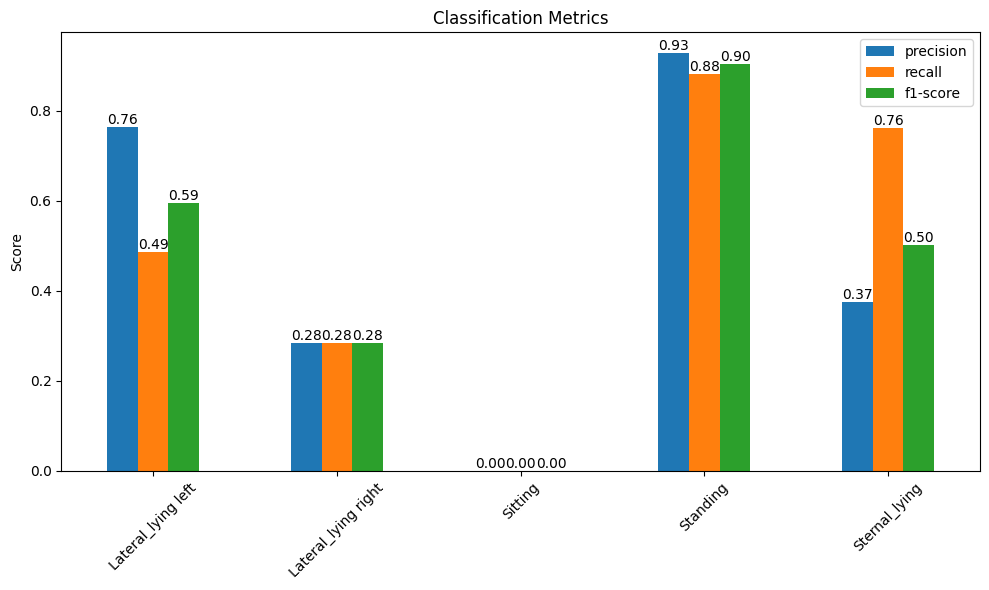

In [36]:
metrics = metrics_df.loc[["0", "1", "2", "3" ,"4"], ["precision", "recall", "f1-score"]]
metrics.index = metrics.index.map({
    "0": "Lateral_lying left",
    "1": "Lateral_lying right",
    "2": "Sitting",
    "3": "Standing",
    "4": "Sternal_lying"
})
ax = metrics.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Classification Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

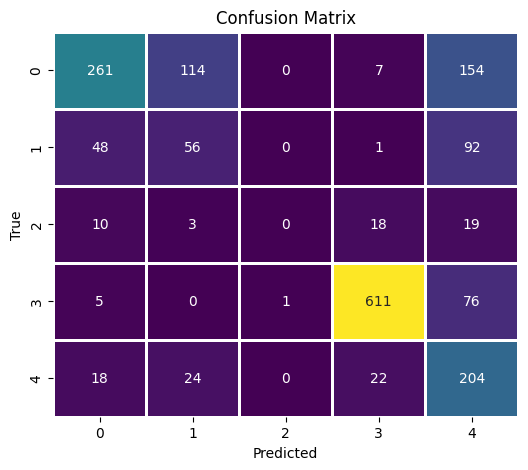

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    cbar=False,
    linewidths=1
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()
